# DINOv2 Regression — k_min, k_max, sigma, beta (Colab)

**Vision Transformer backbone (DINOv2 ViT-S/14) with a 4-output joint regression head.**

Colab-ready version. Prerequisites:
- Upload `balanced_4param_128x128_100000.h5` to `MyDrive/cnn_astro/data/`
- Runtime → Change runtime type → **GPU** (T4 recommended)

Key design choices:
- **3-channel input**: grayscale repeated → RGB (required by ViT patch embedding)
- **112×112 input**: 128×128 data downsampled → 8×8 = 64 patch tokens per image (ViT-S/14)
- **Full fine-tune from epoch 1**: backbone + head jointly (backbone LR 1e-5, head LR 1e-3)
- **Balanced dataset**: joint-uniform rejection sampling over (k_min, k_max); all 4 parameters continuous floats
- **Batch size 64**: fits T4 (15 GB VRAM) comfortably


In [ ]:
# Cell 0 — Colab setup: mount Drive + install missing packages
from google.colab import drive
drive.mount('/content/drive')

import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'h5py', 'scipy'], check=True)
print('Setup done.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup done.


In [ ]:
# Cell 1 — Imports & config
from pathlib import Path
import json, time, sys
import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.manifold import TSNE
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import multiprocessing as mp

# ── Colab paths — adjust DRIVE_ROOT if your folder is named differently ───
DRIVE_ROOT  = Path('/content/drive/MyDrive/thesis_data')
DATA_FILE   = DRIVE_ROOT / 'balanced_4param_128x128_100000.h5'
OUTPUT_DIR  = DRIVE_ROOT / 'outputs' / 'dino_regression_4param'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

assert DATA_FILE.exists(), (
    f'Dataset not found: {DATA_FILE}\n'
    f'Upload balanced_4param_128x128_100000.h5 to MyDrive/cnn_astro/data/'
)

# ── Hyperparams ────────────────────────────────────────────────────────────
SEED          = 42
IMG_SIZE_DINO = 112
EPOCHS        = 50
BATCH_SIZE    = 128
LR_BACKBONE   = 1e-5
LR_HEAD       = 1e-3
NUM_WORKERS   = 2
N_TARGETS     = 4

# ── Parameter bounds ──────────────────────────────────────────────────────
KMIN_LO,  KMIN_HI  = 1.0,  62.0
KMAX_LO,  KMAX_HI  = 3.0,  64.0
LOG_SIG_LO          = float(np.log(0.01))
LOG_SIG_HI          = float(np.log(5.0))
BETA_LO,  BETA_HI  = -3.0, -1.0    # spectral index range

# ── Known turbulence regime reference values (3D power spectrum P(k) ∝ k^β)
BETA_KOLMOGOROV = -11/3   # ≈ -3.67  incompressible (subsonic, Ms << 1)
BETA_KRAICHNAN  = -3.0    # 2D turbulence energy cascade
BETA_BURGERS    = -8/3    # ≈ -2.67  compressible shocks (supersonic, Ms >> 1)

# ── ImageNet normalisation ────────────────────────────────────────────────
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Data    : {DATA_FILE}')
print(f'Output  : {OUTPUT_DIR}')
print(f'Device  : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'Turbulence refs:  Kolmogorov β={BETA_KOLMOGOROV:.3f}  Kraichnan β={BETA_KRAICHNAN:.2f}  Burgers β={BETA_BURGERS:.3f}')


Data    : /content/drive/MyDrive/thesis_data/balanced_4param_128x128_100000.h5
Output  : /content/drive/MyDrive/thesis_data/outputs/dino_regression_4param
Device  : cuda
GPU     : Tesla T4
VRAM    : 15.6 GB
Turbulence refs:  Kolmogorov β=-3.667  Kraichnan β=-3.00  Burgers β=-2.667


In [ ]:
import shutil
LOCAL_FILE = Path('/content/balanced_4param_128x128_100000.h5')
if not LOCAL_FILE.exists():
    print("Copying to local storage...")
    shutil.copy(DATA_FILE, LOCAL_FILE)
DATA_FILE = LOCAL_FILE



Copying to local storage...


In [ ]:
# Cell 2 — Load labels and compute global image percentiles
with h5py.File(DATA_FILE, 'r') as hf:
    n_total    = hf['images'].shape[0]
    kmin_vals  = hf['parameters']['k_min'][:]
    kmax_vals  = hf['parameters']['k_max'][:]
    sigma_vals = hf['parameters']['sigma'][:]
    beta_vals  = hf['parameters']['beta'][:]

np.random.seed(SEED)
samp_idx = np.sort(np.random.choice(n_total, size=2000, replace=False))
with h5py.File(DATA_FILE, 'r') as hf:
    samp = hf['images'][samp_idx]

IMG_P1  = float(np.percentile(samp, 1))
IMG_P99 = float(np.percentile(samp, 99))
del samp

print(f'N = {n_total:,}')
print(f'Image percentiles:  p1={IMG_P1:.4f}  p99={IMG_P99:.4f}')
print(f'k_min:  [{kmin_vals.min():.1f}, {kmin_vals.max():.1f}]   mean={kmin_vals.mean():.2f}')
print(f'k_max:  [{kmax_vals.min():.1f}, {kmax_vals.max():.1f}]   mean={kmax_vals.mean():.2f}')
print(f'sigma:  [{sigma_vals.min():.3f}, {sigma_vals.max():.3f}]  mean={sigma_vals.mean():.3f}')
print(f'beta:   [{beta_vals.min():.3f}, {beta_vals.max():.3f}]  mean={beta_vals.mean():.3f}')


N = 100,000
Image percentiles:  p1=-2.0854  p99=0.9466
k_min:  [1.0, 61.8]   mean=21.32
k_max:  [3.0, 64.0]   mean=43.59
sigma:  [0.010, 5.000]  mean=2.512
beta:   [-3.000, -1.000]  mean=-2.000


In [ ]:
# Cell 3 — Dataset: 4-target, 3-channel ImageNet norm, resize to 112×112
import torch.nn.functional as F

class DINOHdf5Dataset4(Dataset):
    """
    Labels: [k_min_n, k_max_n, log_sigma_n, beta_n] ∈ [0,1]
    Images: p1/p99 clipped → repeat to 3-ch → ImageNet norm → bilinear 112×112
    Lazy HDF5: file handle opened on first __getitem__ (safe with num_workers=0).
    """
    def __init__(self, h5_path, indices, kmin_v, kmax_v, sigma_v, beta_v, img_p1, img_p99):
        self.h5_path   = str(h5_path)
        self.indices   = indices
        self.img_p1    = float(img_p1)
        self.img_range = float(img_p99 - img_p1) + 1e-8
        self.in_mean   = torch.tensor(IMAGENET_MEAN).view(3,1,1)
        self.in_std    = torch.tensor(IMAGENET_STD).view(3,1,1)
        self._h5       = None

        kmin_n  = (kmin_v[indices]  - KMIN_LO) / (KMIN_HI  - KMIN_LO)
        kmax_n  = (kmax_v[indices]  - KMAX_LO) / (KMAX_HI  - KMAX_LO)
        log_sig = np.log(np.clip(sigma_v[indices].astype(np.float64), 1e-9, None))
        sig_n   = (log_sig - LOG_SIG_LO) / (LOG_SIG_HI - LOG_SIG_LO)
        beta_n  = (beta_v[indices]  - BETA_LO) / (BETA_HI  - BETA_LO)

        self.labels = np.stack([kmin_n, kmax_n, sig_n, beta_n], axis=1).astype(np.float32)

    def _get_h5(self):
        if self._h5 is None:
            self._h5 = h5py.File(self.h5_path, 'r')
        return self._h5

    def __len__(self): return len(self.indices)

    def __getitem__(self, idx):
        img = self._get_h5()['images'][self.indices[idx]].astype(np.float32)
        img = np.clip((img - self.img_p1) / self.img_range, 0.0, 1.0)
        t   = torch.from_numpy(img).unsqueeze(0).repeat(3, 1, 1)
        t   = (t - self.in_mean) / self.in_std
        t   = F.interpolate(t.unsqueeze(0), size=(IMG_SIZE_DINO, IMG_SIZE_DINO),
                            mode='bilinear', align_corners=False).squeeze(0)
        return t, torch.from_numpy(self.labels[idx])

    def __del__(self):
        if self._h5 is not None: self._h5.close()

indices = np.arange(n_total)
train_idx, tmp      = train_test_split(indices, test_size=0.2,  random_state=SEED)
val_idx,   test_idx = train_test_split(tmp,     test_size=0.5,  random_state=SEED)

ds_kw = dict(kmin_v=kmin_vals, kmax_v=kmax_vals, sigma_v=sigma_vals,
             beta_v=beta_vals, img_p1=IMG_P1, img_p99=IMG_P99)
train_ds = DINOHdf5Dataset4(DATA_FILE, train_idx, **ds_kw)
val_ds   = DINOHdf5Dataset4(DATA_FILE, val_idx,   **ds_kw)
test_ds  = DINOHdf5Dataset4(DATA_FILE, test_idx,  **ds_kw)

ldr_kw       = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=True)
train_loader = DataLoader(train_ds, shuffle=True,  **ldr_kw)
val_loader   = DataLoader(val_ds,   shuffle=False, **ldr_kw)
test_loader  = DataLoader(test_ds,  shuffle=False, **ldr_kw)

x0, y0 = train_ds[0]
print(f'Train {len(train_ds):,}  Val {len(val_ds):,}  Test {len(test_ds):,}')
print(f'Image shape : {x0.shape}   Label shape : {y0.shape}')
print(f'Label sample (k_min_n, k_max_n, sig_n, beta_n): {y0.numpy().round(4)}')


Train 80,000  Val 10,000  Test 10,000
Image shape : torch.Size([3, 112, 112])   Label shape : torch.Size([4])
Label sample (k_min_n, k_max_n, sig_n, beta_n): [0.0074 0.998  0.9848 0.919 ]


In [ ]:
# Cell 4 — DINOv2 ViT-S/14 backbone + 4-output Sigmoid head
DINO_MODEL = 'dinov2_vits14'
EMBED_DIM  = 384

class DINOv2Regressor(nn.Module):
    def __init__(self, model_name=DINO_MODEL, embed_dim=EMBED_DIM, n_outputs=N_TARGETS):
        super().__init__()
        self.backbone = torch.hub.load(
            'facebookresearch/dinov2', model_name, pretrained=True, verbose=False)
        self.head = nn.Sequential(
            nn.Linear(embed_dim, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 64),        nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, n_outputs),
            nn.Sigmoid()
        )

    def set_backbone_trainable(self, trainable: bool):
        for p in self.backbone.parameters():
            p.requires_grad = trainable

    def forward(self, x):
        return self.head(self.backbone(x))   # (B, N_TARGETS)

    @torch.no_grad()
    def extract_features(self, x):
        return self.backbone(x)              # (B, EMBED_DIM) — raw [CLS] token

model = DINOv2Regressor().to(DEVICE)
n_bb  = sum(p.numel() for p in model.backbone.parameters())
n_hd  = sum(p.numel() for p in model.head.parameters())
print(f'Backbone params : {n_bb:,}')
print(f'Head params     : {n_hd:,}')
print(f'Total           : {n_bb + n_hd:,}')


Backbone params : 22,056,576
Head params     : 115,268
Total           : 22,171,844


In [ ]:
# Cell 5 — Loss, training helpers, denorm (4-target)

class JointRMSELoss(nn.Module):
    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps
    def forward(self, pred, target):
        mse = (pred - target).pow(2).mean(dim=0)
        return torch.sqrt(mse + self.eps).sum()

def train_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    total = 0.0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        if scaler:
            with torch.amp.autocast('cuda'):
                loss = criterion(model(X), y)
            scaler.scale(loss).backward()
            scaler.step(optimizer); scaler.update()
        else:
            loss = criterion(model(X), y)
            loss.backward(); optimizer.step()
        total += loss.item() * len(X)
    return total / len(loader.dataset)

@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total, preds, targets = 0.0, [], []
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        pred = model(X)
        total += criterion(pred, y).item() * len(X)
        preds.append(pred.cpu()); targets.append(y.cpu())
    preds   = torch.cat(preds).numpy()
    targets = torch.cat(targets).numpy()
    return total / len(loader.dataset), np.mean(np.abs(preds - targets), axis=0), preds, targets

TARGET_NAMES = ['k_min', 'k_max', 'sigma', 'beta']

def denorm(preds_n, targets_n):
    """Undo [0,1] normalisation → physical scales."""
    def _d(arr, lo, hi): return arr * (hi - lo) + lo
    p = {
        'k_min':  _d(preds_n[:,0],   KMIN_LO,   KMIN_HI),
        'k_max':  _d(preds_n[:,1],   KMAX_LO,   KMAX_HI),
        'sigma':  np.exp(_d(preds_n[:,2], LOG_SIG_LO, LOG_SIG_HI)),
        'beta':   _d(preds_n[:,3],   BETA_LO,   BETA_HI),
    }
    t = {
        'k_min':  _d(targets_n[:,0], KMIN_LO,   KMIN_HI),
        'k_max':  _d(targets_n[:,1], KMAX_LO,   KMAX_HI),
        'sigma':  np.exp(_d(targets_n[:,2], LOG_SIG_LO, LOG_SIG_HI)),
        'beta':   _d(targets_n[:,3], BETA_LO,   BETA_HI),
    }
    return p, t

print('Helpers defined.')


Helpers defined.


In [ ]:
# Cell 6 — Smoke test (500 train / 200 val, 5 epochs, fully unfrozen)
rng = np.random.RandomState(SEED)
sm_train = DataLoader(Subset(train_ds, rng.choice(len(train_ds), 500, replace=False)),
                      batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
sm_val   = DataLoader(Subset(val_ds,   rng.choice(len(val_ds),   200, replace=False)),
                      batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

sm   = DINOv2Regressor().to(DEVICE)
sm.set_backbone_trainable(True)
crit = JointRMSELoss().to(DEVICE)
opt  = optim.AdamW([{'params': sm.backbone.parameters(), 'lr': LR_BACKBONE, 'weight_decay': 1e-4},
                    {'params': sm.head.parameters(),     'lr': LR_HEAD,     'weight_decay': 1e-4}])
sc   = torch.amp.GradScaler('cuda') if DEVICE.type == 'cuda' else None

for ep in range(5):
    tl = train_epoch(sm, sm_train, crit, opt, sc, DEVICE)
    vl, vm, _, _ = eval_epoch(sm, sm_val, crit, DEVICE)
    print(f'Smoke ep {ep+1}/5 | train {tl:.4f} | val {vl:.4f} '
          f'| kmin={vm[0]:.3f} kmax={vm[1]:.3f} sig={vm[2]:.3f} beta={vm[3]:.3f}')
del sm, opt, sc
print('Smoke test passed.')


Smoke ep 1/5 | train 1.0329 | val 0.8362 | kmin=0.147 kmax=0.223 sig=0.093 beta=0.252
Smoke ep 2/5 | train 0.8003 | val 0.6884 | kmin=0.078 kmax=0.208 sig=0.046 beta=0.236
Smoke ep 3/5 | train 0.6952 | val 0.6306 | kmin=0.045 kmax=0.190 sig=0.052 beta=0.231
Smoke ep 4/5 | train 0.6413 | val 0.5807 | kmin=0.042 kmax=0.171 sig=0.039 beta=0.221
Smoke ep 5/5 | train 0.6181 | val 0.5753 | kmin=0.043 kmax=0.166 sig=0.038 beta=0.224
Smoke test passed.


In [ ]:
# Cell 7 — Full training: end-to-end fine-tune (resume-safe)
results_path = OUTPUT_DIR / 'results.json'
best_ckpt    = OUTPUT_DIR / 'best_model.pt'

if results_path.exists():
    print(f'[SKIP] results.json exists — jump to Cell 8')
else:
    model     = DINOv2Regressor().to(DEVICE)
    model.set_backbone_trainable(True)
    criterion = JointRMSELoss().to(DEVICE)
    scaler    = torch.amp.GradScaler('cuda') if DEVICE.type == 'cuda' else None
    optimizer = optim.AdamW([
        {'params': model.backbone.parameters(), 'lr': LR_BACKBONE, 'weight_decay': 1e-4},
        {'params': model.head.parameters(),     'lr': LR_HEAD,     'weight_decay': 1e-4},
    ])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-7)

    history  = {k: [] for k in ['train_loss','val_loss',
                                 'val_mae_kmin','val_mae_kmax','val_mae_sigma','val_mae_beta']}
    best_val = float('inf')
    t0       = time.time()

    print(f'Full fine-tune: {EPOCHS} epochs  |  backbone LR={LR_BACKBONE}  head LR={LR_HEAD}')
    for epoch in range(EPOCHS):
        tl           = train_epoch(model, train_loader, criterion, optimizer, scaler, DEVICE)
        vl, vm, _, _ = eval_epoch(model, val_loader,   criterion, DEVICE)
        scheduler.step()
        for k, v in zip(['train_loss','val_loss','val_mae_kmin','val_mae_kmax','val_mae_sigma','val_mae_beta'],
                        [tl, vl, vm[0], vm[1], vm[2], vm[3]]):
            history[k].append(float(v))
        mem = torch.cuda.memory_reserved() / 1e9 if torch.cuda.is_available() else 0.0
        print(f'  Ep {epoch+1:2d}/{EPOCHS} | train {tl:.4f} | val {vl:.4f} '
              f'| kmin={vm[0]:.4f} kmax={vm[1]:.4f} sig={vm[2]:.4f} beta={vm[3]:.4f} '
              f'| VRAM {mem:.1f}GB')
        if vl < best_val:
            best_val = vl
            torch.save(model.state_dict(), best_ckpt)
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    training_time = (time.time() - t0) / 60
    print(f'\nDone in {training_time:.1f} min  |  best val: {best_val:.4f}')

    model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))
    _, _, y_pred_n, y_true_n = eval_epoch(model, test_loader, criterion, DEVICE)
    y_pred_d, y_true_d = denorm(y_pred_n, y_true_n)
    metrics = {p: {'mae':  float(mean_absolute_error(y_true_d[p], y_pred_d[p])),
                   'rmse': float(np.sqrt(mean_squared_error(y_true_d[p], y_pred_d[p]))),
                   'r2':   float(r2_score(y_true_d[p], y_pred_d[p]))}
               for p in TARGET_NAMES}

    results = {'history': history, 'metrics': metrics,
               'y_true': {p: y_true_d[p].tolist() for p in TARGET_NAMES},
               'y_pred': {p: y_pred_d[p].tolist() for p in TARGET_NAMES},
               'training_time_min': training_time, 'best_val_loss': best_val}
    with open(results_path, 'w') as f: json.dump(results, f)
    print(f'Results saved → {results_path}')


Full fine-tune: 50 epochs  |  backbone LR=1e-05  head LR=0.001
  Ep  1/50 | train 0.4785 | val 0.3744 | kmin=0.0194 kmax=0.0986 sig=0.0161 beta=0.1512 | VRAM 2.8GB
  Ep  2/50 | train 0.4108 | val 0.3508 | kmin=0.0121 kmax=0.0896 sig=0.0114 beta=0.1422 | VRAM 2.8GB
  Ep  3/50 | train 0.3837 | val 0.3499 | kmin=0.0123 kmax=0.0890 sig=0.0159 beta=0.1390 | VRAM 2.8GB
  Ep  4/50 | train 0.3680 | val 0.3288 | kmin=0.0144 kmax=0.0822 sig=0.0111 beta=0.1284 | VRAM 2.8GB
  Ep  5/50 | train 0.3538 | val 0.3544 | kmin=0.0135 kmax=0.0890 sig=0.0106 beta=0.1480 | VRAM 2.8GB
  Ep  6/50 | train 0.3401 | val 0.3306 | kmin=0.0127 kmax=0.0852 sig=0.0098 beta=0.1310 | VRAM 2.8GB
  Ep  7/50 | train 0.3249 | val 0.3169 | kmin=0.0135 kmax=0.0785 sig=0.0091 beta=0.1251 | VRAM 2.8GB
  Ep  8/50 | train 0.3163 | val 0.3240 | kmin=0.0117 kmax=0.0799 sig=0.0139 beta=0.1238 | VRAM 2.8GB
  Ep  9/50 | train 0.3025 | val 0.3303 | kmin=0.0119 kmax=0.0810 sig=0.0099 beta=0.1330 | VRAM 2.8GB
  Ep 10/50 | train 0.2888 | 

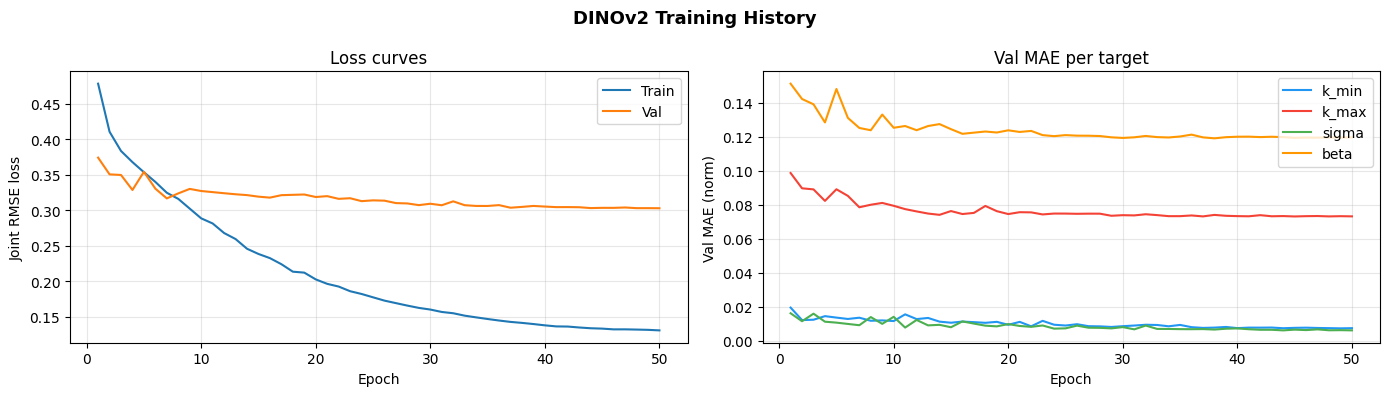

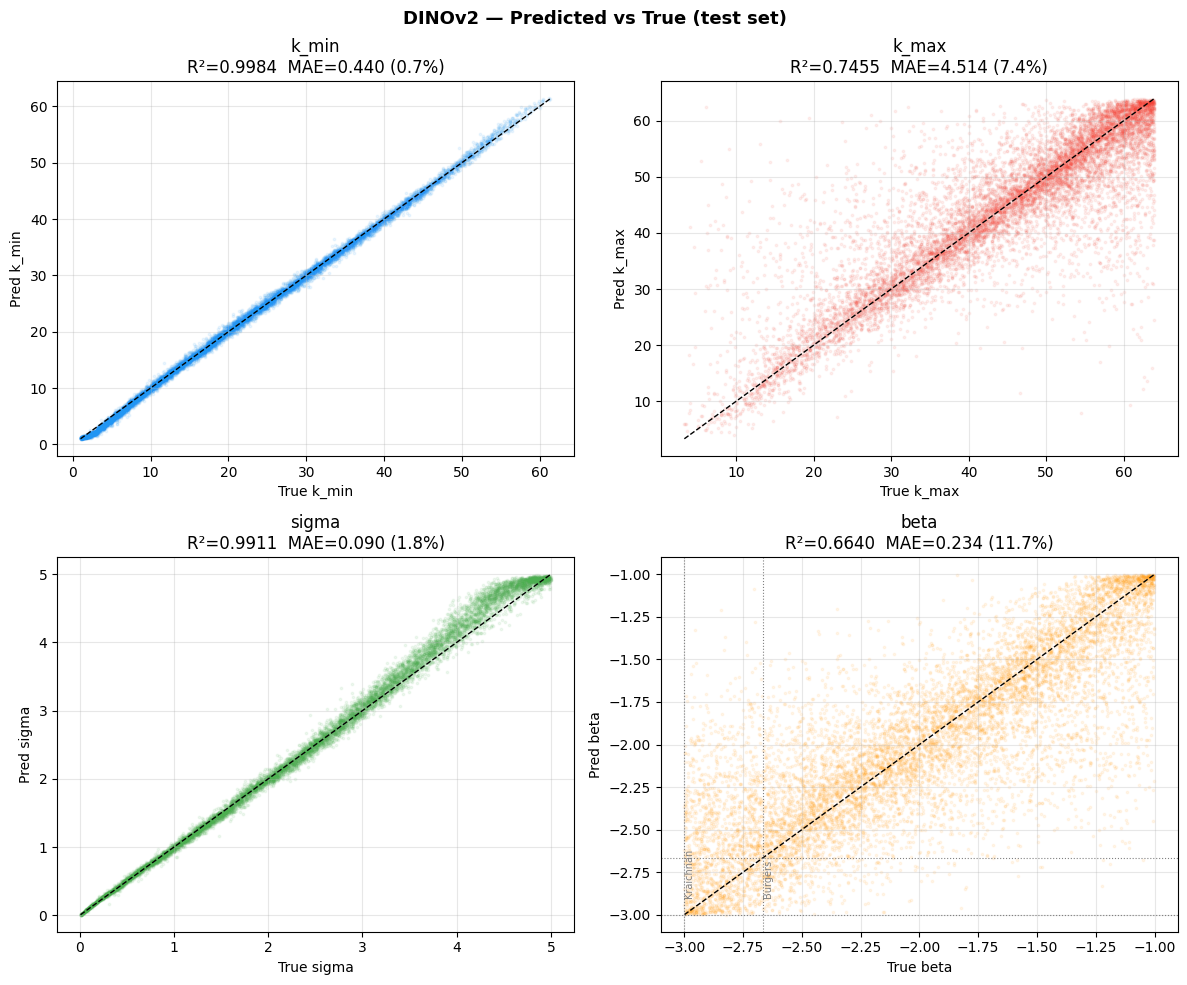


PARAM         MAE     RMSE       R²   % range
------------------------------------------------------------
k_min       0.440    0.563   0.9984      0.7%
k_max       4.514    7.271   0.7455      7.4%
sigma       0.090    0.136   0.9911      1.8%
beta        0.234    0.334   0.6640     11.7%


In [ ]:
# Cell 8 — Evaluation plots (training curves + predicted vs true, 4 targets)
if 'results' not in globals():
    with open(results_path) as f: results = json.load(f)
    print(f'Loaded {results_path}')

COLORS = {'k_min': '#2196F3', 'k_max': '#F44336', 'sigma': '#4CAF50', 'beta': '#FF9800'}
h = results['history']
ep_range = range(1, len(h['train_loss']) + 1)

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(ep_range, h['train_loss'], label='Train')
axes[0].plot(ep_range, h['val_loss'],   label='Val')
axes[0].set(xlabel='Epoch', ylabel='Joint RMSE loss', title='Loss curves')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
for p, key in zip(TARGET_NAMES, ['val_mae_kmin','val_mae_kmax','val_mae_sigma','val_mae_beta']):
    axes[1].plot(ep_range, h[key], label=p, color=COLORS[p])
axes[1].set(xlabel='Epoch', ylabel='Val MAE (norm)', title='Val MAE per target')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.suptitle('DINOv2 Training History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Predicted vs True (2×2)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
RANGES = {'k_min': KMIN_HI-KMIN_LO, 'k_max': KMAX_HI-KMAX_LO,
          'sigma': np.exp(LOG_SIG_HI)-np.exp(LOG_SIG_LO), 'beta': BETA_HI-BETA_LO}
for ax, p in zip(axes.flat, TARGET_NAMES):
    yt = np.array(results['y_true'][p])
    yp = np.array(results['y_pred'][p])
    m  = results['metrics'][p]
    ax.scatter(yt, yp, alpha=0.08, s=3, color=COLORS[p], rasterized=True)
    lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lims, lims, 'k--', lw=1)
    if p == 'beta':
        for bval, blabel in [(BETA_KRAICHNAN,'Kraichnan'), (BETA_BURGERS,'Burgers')]:
            ax.axvline(bval, color='gray', lw=0.8, ls=':')
            ax.axhline(bval, color='gray', lw=0.8, ls=':')
            ax.text(bval, lims[0]+0.05*(lims[1]-lims[0]), blabel,
                    rotation=90, fontsize=7, color='gray', va='bottom')
    pct = 100 * m['mae'] / RANGES[p]
    ax.set(xlabel=f'True {p}', ylabel=f'Pred {p}',
           title=f'{p}\nR²={m["r2"]:.4f}  MAE={m["mae"]:.3f} ({pct:.1f}%)')
    ax.grid(True, alpha=0.3)
plt.suptitle('DINOv2 — Predicted vs True (test set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'scatter.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print(f"\n{'='*60}")
print(f"{'PARAM':<8} {'MAE':>8} {'RMSE':>8} {'R²':>8}  {'% range':>8}")
print(f"{'-'*60}")
for p in TARGET_NAMES:
    m   = results['metrics'][p]
    pct = 100 * m['mae'] / RANGES[p]
    print(f"{p:<8} {m['mae']:>8.3f} {m['rmse']:>8.3f} {m['r2']:>8.4f}  {pct:>7.1f}%")
print(f"{'='*60}")


## Latent Space Analysis

The DINOv2 [CLS] token (384-dim) is a compressed description of the image that the ViT backbone has learned to produce. We project it to 2D via t-SNE and ask: **which physical parameters does this representation encode, and how?**

We produce four figures:

1. **Parameter maps** — t-SNE coloured by each of the 4 targets (k_min, k_max, σ, β)  
2. **Turbulence regime map** — discrete colouring by spectral index β, annotated with reference regimes (Kraichnan, Burgers). β is a proxy for the *turbulence energy cascade type* and therefore for the **sonic Mach number** Ms:  
   - β → −3 (steep spectrum) : large-scale dominated, subsonic / incompressible (Ms ≲ 1)  
   - β → −8/3 (Burgers) : shock-dominated, highly supersonic (Ms ≫ 1)  
   - β → −1 (shallow) : small-scale dominated, extreme compressibility  
3. **Spearman correlation heatmap** — quantifies how strongly each t-SNE axis correlates with each physical parameter  
4. **Physical parameter space** — k_min vs k_max coloured by β, with σ encoded as point size; shows the full regime coverage the model operates over


Embeddings: (5000, 384)
Running t-SNE...
t-SNE done. KL divergence: 1.3052


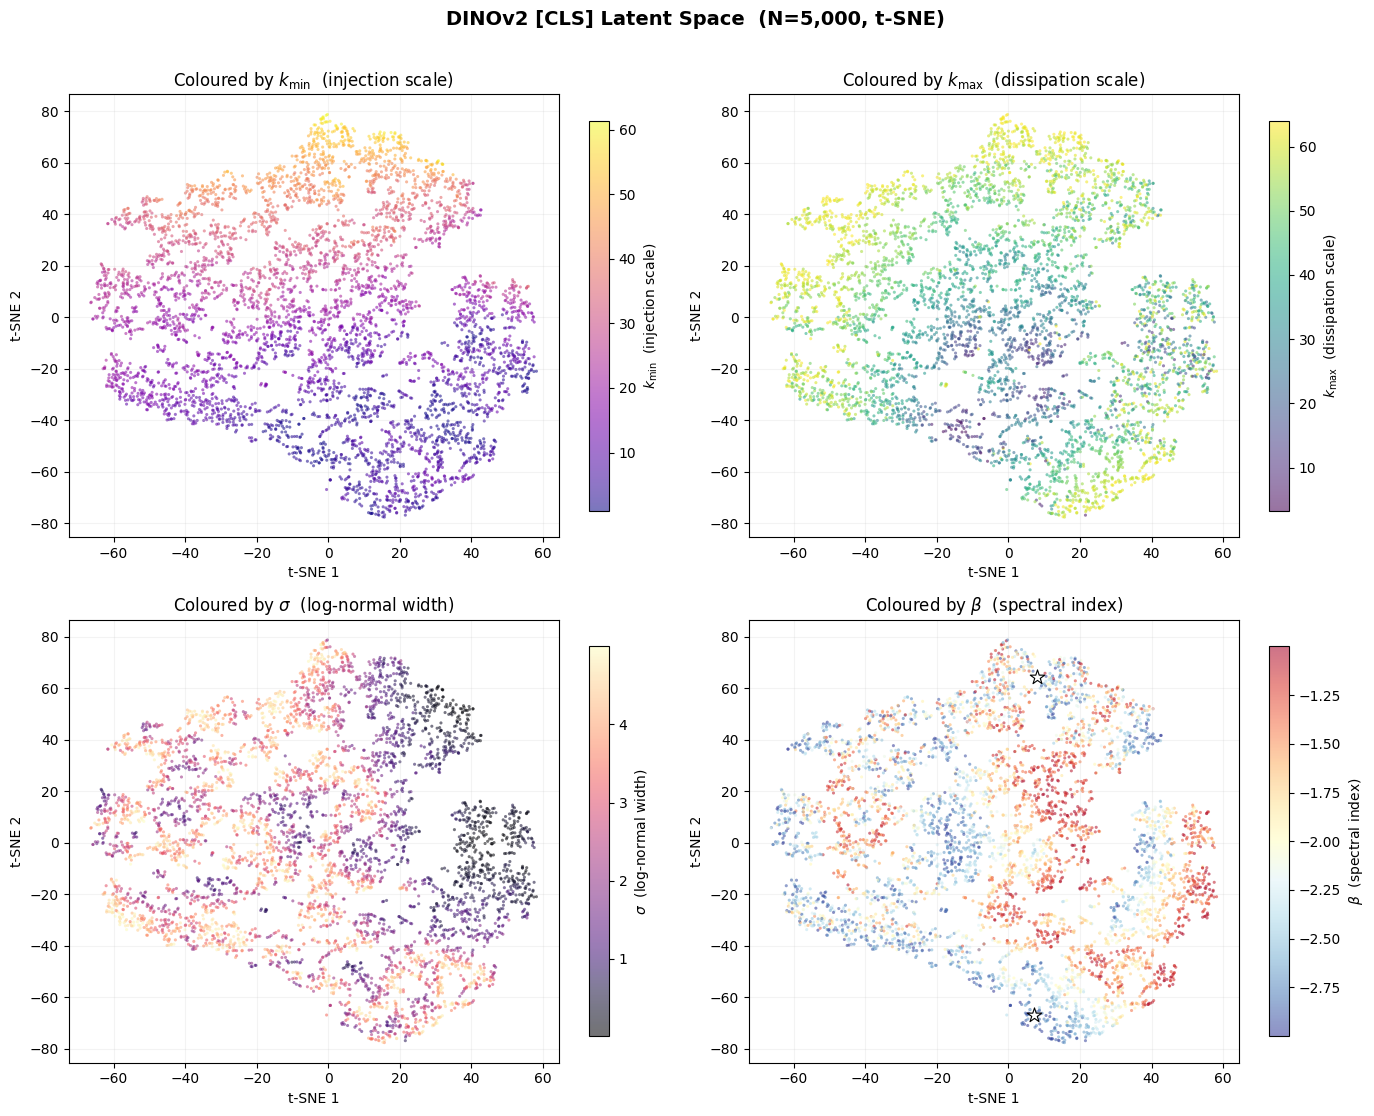

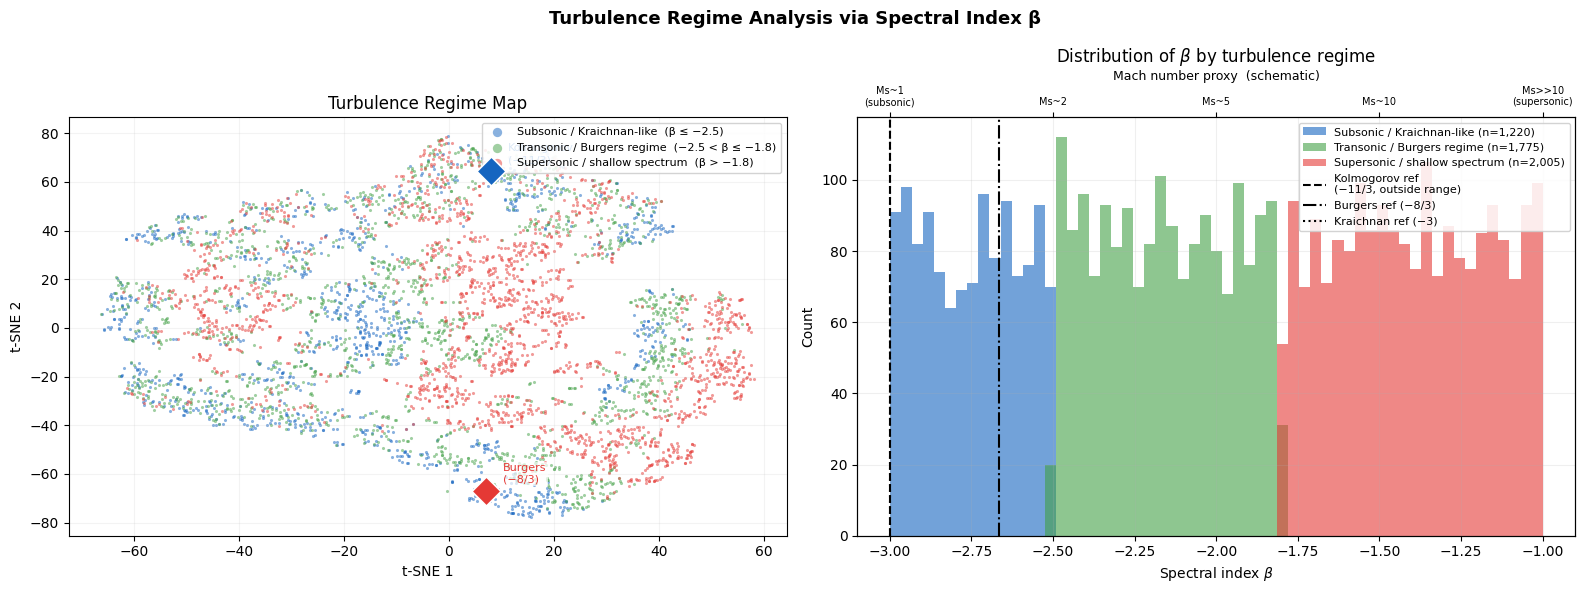

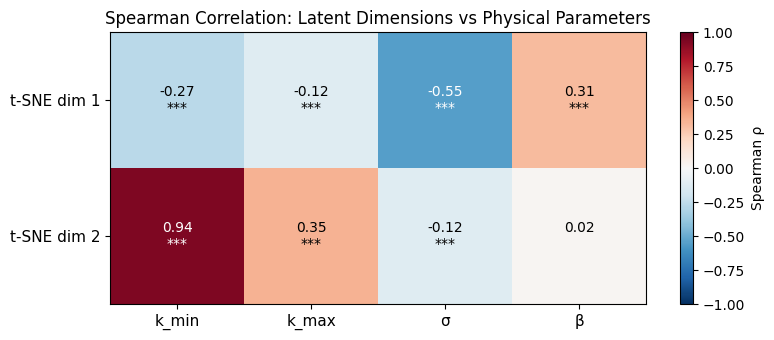

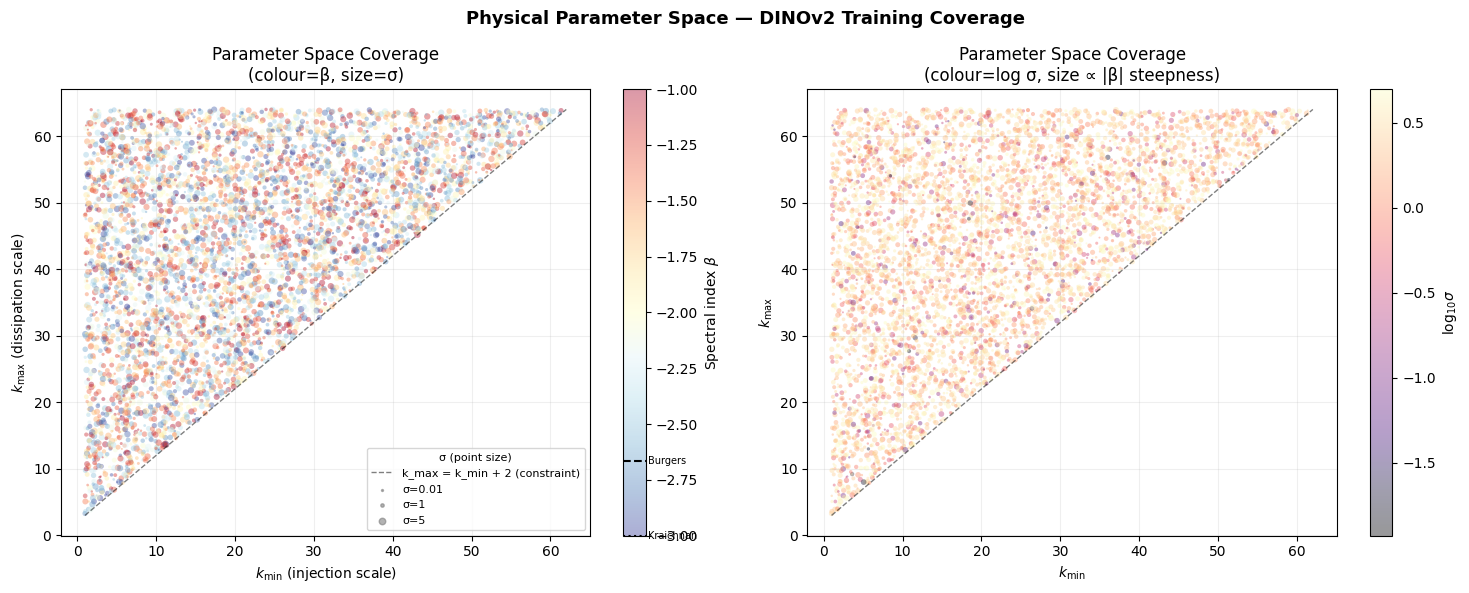

In [ ]:
# Cell 9 — Latent space extraction + t-SNE + regime analysis

N_LATENT = 5000   # larger sample for richer visualisation on Colab

# ── Load model ─────────────────────────────────────────────────────────────
if 'model' not in globals():
    model = DINOv2Regressor().to(DEVICE)
model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))
model.eval()

# ── Extract embeddings ─────────────────────────────────────────────────────
rng     = np.random.RandomState(SEED)
lat_idx = rng.choice(len(test_ds), min(N_LATENT, len(test_ds)), replace=False)
lat_ldr = DataLoader(Subset(test_ds, lat_idx), batch_size=128, shuffle=False, num_workers=0)

embeddings, labels_all = [], []
with torch.no_grad():
    for X, y in lat_ldr:
        embeddings.append(model.extract_features(X.to(DEVICE)).cpu().numpy())
        labels_all.append(y.numpy())

embeddings = np.concatenate(embeddings)  # (N, 384)
labels_all = np.concatenate(labels_all)  # (N, 4)

# Denorm to physical scales
lab_kmin  = labels_all[:,0] * (KMIN_HI - KMIN_LO) + KMIN_LO
lab_kmax  = labels_all[:,1] * (KMAX_HI - KMAX_LO) + KMAX_LO
lab_sigma = np.exp(labels_all[:,2] * (LOG_SIG_HI - LOG_SIG_LO) + LOG_SIG_LO)
lab_beta  = labels_all[:,3] * (BETA_HI - BETA_LO) + BETA_LO

print(f'Embeddings: {embeddings.shape}')

# ── t-SNE projection ───────────────────────────────────────────────────────
print('Running t-SNE...')
tsne = TSNE(n_components=2, perplexity=40, learning_rate='auto',
            init='pca', random_state=SEED, max_iter=1500)
proj = tsne.fit_transform(embeddings)
print(f't-SNE done. KL divergence: {tsne.kl_divergence_:.4f}')

# ═══════════════════════════════════════════════════════════════════════════
# Figure 1 — 4-panel t-SNE coloured by each physical parameter
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
param_cfg = [
    ('k_min',  lab_kmin,  'plasma',   r'$k_{\min}$  (injection scale)'),
    ('k_max',  lab_kmax,  'viridis',  r'$k_{\max}$  (dissipation scale)'),
    ('sigma',  lab_sigma, 'magma',    r'$\sigma$  (log-normal width)'),
    ('beta',   lab_beta,  'RdYlBu_r', r'$\beta$  (spectral index)'),
]
for ax, (name, vals, cmap, label) in zip(axes.flat, param_cfg):
    sc = ax.scatter(proj[:,0], proj[:,1], c=vals, cmap=cmap,
                    s=5, alpha=0.55, rasterized=True, linewidths=0)
    cb = plt.colorbar(sc, ax=ax, label=label, shrink=0.88)
    if name == 'beta':
        for bref, blbl in [(BETA_KRAICHNAN, 'Kraichnan'), (BETA_BURGERS, 'Burgers')]:
            idx_ref = np.argmin(np.abs(lab_beta - bref))
            ax.scatter(*proj[idx_ref], s=120, marker='*', c='white',
                       edgecolors='black', linewidths=0.8, zorder=5)
    ax.set(xlabel='t-SNE 1', ylabel='t-SNE 2', title=f'Coloured by {label}')
    ax.grid(True, alpha=0.15)
plt.suptitle(f'DINOv2 [CLS] Latent Space  (N={len(proj):,}, t-SNE)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'latent_tsne_4param.png', dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# Figure 2 — Turbulence regime map (beta binned → discrete colours)
# ═══════════════════════════════════════════════════════════════════════════
def regime_label(b):
    if   b <= -2.5: return 'Subsonic / Kraichnan-like  (β ≤ −2.5)'
    elif b <= -1.8: return 'Transonic / Burgers regime  (−2.5 < β ≤ −1.8)'
    else:           return 'Supersonic / shallow spectrum  (β > −1.8)'

regime_names  = ['Subsonic / Kraichnan-like  (β ≤ −2.5)',
                 'Transonic / Burgers regime  (−2.5 < β ≤ −1.8)',
                 'Supersonic / shallow spectrum  (β > −1.8)']
regime_colors = ['#1565C0', '#43A047', '#E53935']

regimes = np.array([regime_label(b) for b in lab_beta])
regime_idx = np.array([regime_names.index(r) for r in regimes])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
for ri, (rname, rcol) in enumerate(zip(regime_names, regime_colors)):
    mask = regime_idx == ri
    ax.scatter(proj[mask, 0], proj[mask, 1], c=rcol, s=5, alpha=0.5,
               label=rname, rasterized=True, linewidths=0)

for bref, blbl, col in [(BETA_KRAICHNAN,'Kolmogorov\n(−11/3)','#1565C0'),
                         (BETA_BURGERS,  'Burgers\n(−8/3)',    '#E53935')]:
    idx_ref = np.argmin(np.abs(lab_beta - bref))
    ax.scatter(*proj[idx_ref], s=220, marker='D', c=col,
               edgecolors='white', linewidths=1.2, zorder=6)
    ax.annotate(blbl, proj[idx_ref], fontsize=8, color=col,
                xytext=(12, 6), textcoords='offset points',
                bbox=dict(fc='white', alpha=0.7, pad=1, ec='none'))

ax.set(xlabel='t-SNE 1', ylabel='t-SNE 2', title='Turbulence Regime Map')
ax.legend(loc='upper right', fontsize=8, markerscale=3, framealpha=0.85)
ax.grid(True, alpha=0.15)

ax2 = axes[1]
bins = np.linspace(BETA_LO, BETA_HI, 60)
for ri, (rname, rcol) in enumerate(zip(regime_names, regime_colors)):
    mask = regime_idx == ri
    ax2.hist(lab_beta[mask], bins=bins, color=rcol, alpha=0.6,
             label=f'{rname.split("(")[0].strip()} (n={mask.sum():,})', edgecolor='none')

for bref, blbl, ls in [(BETA_KRAICHNAN,'Kolmogorov ref\n(−11/3, outside range)','--'),
                        (BETA_BURGERS,  'Burgers ref (−8/3)','-.'),
                        (BETA_KRAICHNAN*0 + BETA_LO, 'Kraichnan ref (−3)',':')]:
    if BETA_LO <= bref <= BETA_HI:
        ax2.axvline(bref, color='black', lw=1.5, ls=ls, label=blbl)

ax2b = ax2.twiny()
ax2b.set_xlim(ax2.get_xlim())
proxy_ticks  = [-3.0, -2.5, -2.0, -1.5, -1.0]
proxy_labels = ['Ms~1\n(subsonic)', 'Ms~2', 'Ms~5', 'Ms~10', 'Ms>>10\n(supersonic)']
ax2b.set_xticks(proxy_ticks)
ax2b.set_xticklabels(proxy_labels, fontsize=7)
ax2b.set_xlabel('Mach number proxy  (schematic)', fontsize=9)

ax2.set(xlabel=r'Spectral index $\beta$', ylabel='Count',
        title=r'Distribution of $\beta$ by turbulence regime')
ax2.legend(fontsize=8, framealpha=0.85)
ax2.grid(True, alpha=0.2)

plt.suptitle('Turbulence Regime Analysis via Spectral Index β',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'latent_regimes.png', dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# Figure 3 — Spearman correlation: latent dims vs physical parameters
# ═══════════════════════════════════════════════════════════════════════════
phys_params = {'k_min': lab_kmin, 'k_max': lab_kmax, 'sigma': lab_sigma, 'beta': lab_beta}
corr_matrix = np.zeros((2, 4))   # [tsne_dim1, tsne_dim2] × [k_min, k_max, sigma, beta]
pval_matrix = np.zeros((2, 4))

for j, (pname, pvals) in enumerate(phys_params.items()):
    for i, dim in enumerate([0, 1]):
        r, p = spearmanr(proj[:, dim], pvals)
        corr_matrix[i, j] = r
        pval_matrix[i, j]  = p

fig, ax = plt.subplots(figsize=(8, 3.5))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Spearman ρ')

ax.set_xticks(range(4)); ax.set_xticklabels(['k_min', 'k_max', 'σ', 'β'], fontsize=11)
ax.set_yticks([0, 1]);   ax.set_yticklabels(['t-SNE dim 1', 't-SNE dim 2'], fontsize=11)
ax.set_title('Spearman Correlation: Latent Dimensions vs Physical Parameters', fontsize=12)

for i in range(2):
    for j in range(4):
        pval = pval_matrix[i, j]
        sig  = '***' if pval < 1e-10 else ('**' if pval < 1e-5 else ('*' if pval < 0.05 else ''))
        txt  = f'{corr_matrix[i,j]:.2f}\n{sig}'
        ax.text(j, i, txt, ha='center', va='center', fontsize=10,
                color='white' if abs(corr_matrix[i,j]) > 0.5 else 'black')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'latent_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════
# Figure 4 — Physical parameter space: k_min vs k_max coloured by β, size=σ
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: physical parameter space
ax = axes[0]
sz = 2 + 20 * (lab_sigma - lab_sigma.min()) / (lab_sigma.max() - lab_sigma.min() + 1e-8)
sc = ax.scatter(lab_kmin, lab_kmax, c=lab_beta, s=sz, alpha=0.4,
                cmap='RdYlBu_r', vmin=BETA_LO, vmax=BETA_HI,
                rasterized=True, linewidths=0)
cb = plt.colorbar(sc, ax=ax, label=r'Spectral index $\beta$')

cb.ax.axhline(BETA_BURGERS,   color='black', lw=1.5, ls='--')
cb.ax.axhline(BETA_KRAICHNAN, color='black', lw=1.5, ls=':')
cb.ax.text(1.1, (BETA_BURGERS - BETA_LO)/(BETA_HI-BETA_LO),
           'Burgers', transform=cb.ax.transAxes, fontsize=7, va='center')
cb.ax.text(1.1, (BETA_KRAICHNAN - BETA_LO)/(BETA_HI-BETA_LO),
           'Kraichnan', transform=cb.ax.transAxes, fontsize=7, va='center')

kmin_line = np.linspace(KMIN_LO, KMIN_HI, 100)
ax.plot(kmin_line, kmin_line + 2, 'k--', lw=1, alpha=0.5, label='k_max = k_min + 2 (constraint)')
ax.set(xlabel=r'$k_{\min}$ (injection scale)', ylabel=r'$k_{\max}$ (dissipation scale)',
       title='Parameter Space Coverage\n(colour=β, size=σ)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.2)

# Right
ax2 = axes[1]
sz2 = 2 + 15 * (BETA_HI - lab_beta) / (BETA_HI - BETA_LO)
sc2 = ax2.scatter(lab_kmin, lab_kmax, c=np.log10(lab_sigma), s=sz2, alpha=0.4,
                  cmap='magma', rasterized=True, linewidths=0)
plt.colorbar(sc2, ax=ax2, label=r'log$_{10}\sigma$')
ax2.plot(kmin_line, kmin_line + 2, 'k--', lw=1, alpha=0.5)
ax2.set(xlabel=r'$k_{\min}$', ylabel=r'$k_{\max}$',
        title='Parameter Space Coverage\n(colour=log σ, size ∝ |β| steepness)')
ax2.grid(True, alpha=0.2)

for sig_ex, lbl in [(0.01,'σ=0.01'), (1.0,'σ=1'), (5.0,'σ=5')]:
    ax.scatter([], [], s=2+20*(sig_ex-lab_sigma.min())/(lab_sigma.max()-lab_sigma.min()+1e-8),
               c='gray', alpha=0.6, label=lbl)
ax.legend(fontsize=8, title='σ (point size)', title_fontsize=8)

plt.suptitle('Physical Parameter Space — DINOv2 Training Coverage',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'parameter_space.png', dpi=150, bbox_inches='tight')
plt.show()